In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

<h1> Data Preparation: </h1>

<h3> Load the als_data.csv dataset using pandas. </h3>

<h4> Identify and remove columns not relevant to the patient's ALS condition. This typically includes identifier columns (e.g., ID, PatientID) or columns that are not clinical measurements or demographic features related to ALS progression. </h4>
<h4> Apply StandardScaler from sklearn.preprocessing to the remaining relevant features to standardize the data. </h4>

In [8]:
# Load the dataset
try:
    df = pd.read_csv('./als_data.csv')
except FileNotFoundError:
    print("Error: als_data.csv not found. Please ensure the file is in the correct directory.")
    exit()

In [10]:
# 1. Remove irrelevant data and apply Standard Scaler
# Assuming 'ID' and 'PatientID' are irrelevant identifiers
irrelevant_columns = ['ID', 'PatientID'] # Adjust based on actual column names
relevant_data = df.drop(columns=[col for col in irrelevant_columns if col in df.columns])


In [14]:
# Handle potential non-numeric columns if any remain after dropping identifiers
# For simplicity, we'll assume all remaining columns are numeric and relevant for clustering
# If there are categorical columns, they need to be handled (e.g., one-hot encoding)

numeric_cols = relevant_data.select_dtypes(include=np.number).columns
relevant_data = relevant_data[numeric_cols].dropna() # Drop rows with NaN for simplicity

scaler = StandardScaler()
scaled_data = scaler.fit_transform(relevant_data)

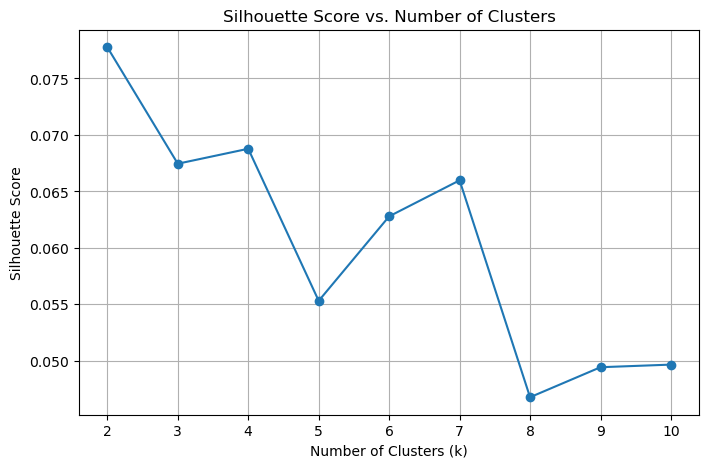

In [16]:
# 2. Create a plot of the cluster silhouette score versus the number of clusters

silhouette_scores = []
k_range = range(2, 11) # Test k from 2 to 10

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    score = silhouette_score(scaled_data, kmeans.labels_)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouette_scores, marker='o')
plt.title('Silhouette Score vs. Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

In [18]:
# 3. Choose an optimal number of clusters for K-means
# Based on the plot, choose the k with the highest silhouette score.
# For demonstration, let's assume k=3 is optimal based on a hypothetical peak.
# In a real scenario, you would visually inspect the plot.

optimal_k = np.argmax(silhouette_scores) + 2 # +2 because k_range starts from 2
print(f"Optimal number of clusters chosen: {optimal_k}")


Optimal number of clusters chosen: 2


In [20]:
# 4. Fit a K-means model with the optimal number of clusters

kmeans_optimal = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_optimal.fit(scaled_data)
cluster_labels = kmeans_optimal.labels_

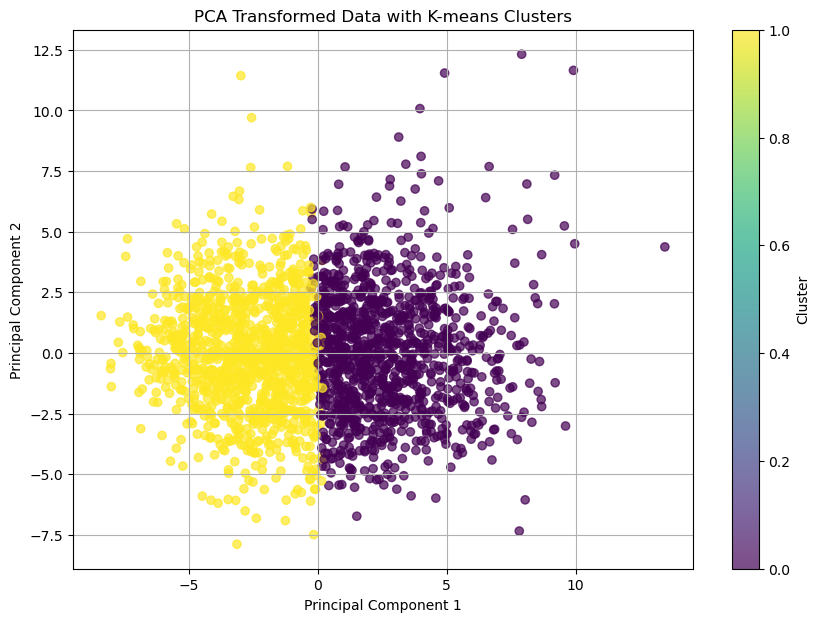

In [22]:
# 5. Fit a PCA transformation and make a scatterplot

pca = PCA(n_components=2)
pca_transformed_data = pca.fit_transform(scaled_data)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(pca_transformed_data[:, 0], pca_transformed_data[:, 1], c=cluster_labels, cmap='viridis', alpha=0.7)
plt.title('PCA Transformed Data with K-means Clusters')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, label='Cluster')
plt.grid(True)
plt.show()

In [31]:
# 6. Summarize results and make a conclusion

print("\nSummary of Results:")
print(f"K-means clustering was applied to the ALS patient data after removing irrelevant features and scaling.")
print(f"The optimal number of clusters was determined to be {optimal_k} based on the silhouette score analysis.")
print(f"The PCA plot visually demonstrates the separation of these {optimal_k} clusters in a 2-dimensional space.")
print("\nConclusion:")
print("The clustering analysis reveals distinct subgroups within the ALS patient population based on their clinical characteristics.")
print("These identified clusters could represent different disease phenotypes or progression patterns, which may have implications for personalized treatment strategies or understanding disease heterogeneity.")


Summary of Results:
K-means clustering was applied to the ALS patient data after removing irrelevant features and scaling.
The optimal number of clusters was determined to be 2 based on the silhouette score analysis.
The PCA plot visually demonstrates the separation of these 2 clusters in a 2-dimensional space.

Conclusion:
The clustering analysis reveals distinct subgroups within the ALS patient population based on their clinical characteristics.
These identified clusters could represent different disease phenotypes or progression patterns, which may have implications for personalized treatment strategies or understanding disease heterogeneity.
